# TMD (legacy) demo: 0D persistence barcodes + persistence images

"
"This notebook demonstrates how to use the **older** conditioning utilities in `utils/tmd_conditioning_utils.py`
"
"to compute **0D persistence diagrams**, **barcodes**, and **persistence images** for rooted tree graphs.
"
"It mirrors `notebooks/tmd_paper_demo.ipynb`, but **does not** use `tmd_paper_embedding_utils.py`.


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import os, sys
from pathlib import Path
sys.path.append(os.path.abspath('..'))

from utils.tmd_conditioning_utils import (
    filtration_path_length_from_root,
    filtration_height_z,
    filtration_radial_rho,
    normalize_filtration_values,
    compute_0d_persistence_diagram,
    persistence_image,
    compute_tmd_global_embedding,
)

from utils.data_loading import load_swc_graphs_from_dir, load_swc_graph


## 1) Load rooted trees from your dataset (SWC)

"
"This uses `utils.data_loading.load_swc_graphs_from_dir` to read cleaned SWC files.


In [45]:
# Point this at your cleaned SWC dataset root
DATA_ROOT = Path('/Volumes/Seagate/small_trees_test_v3')  # <-- change to your dataset root
SPLIT = 'train'  # 'train' | 'val' | 'test'
SWC_DIR = DATA_ROOT / SPLIT

# Option A: load a directory of SWC files
graphs = load_swc_graphs_from_dir(SWC_DIR)
if len(graphs) == 0:
    raise RuntimeError(f'No SWC graphs found under: {SWC_DIR}')
print(f'Loaded {len(graphs)} graphs from {SWC_DIR}')

# Pick one tree to visualize in the next sections
GRAPH_IDX = 1
G = graphs[GRAPH_IDX]

# Option B (single file):
# SINGLE_SWC = Path('/path/to/file.csv.swc')
# G = load_swc_graph(SINGLE_SWC)


Loaded 3 graphs from /Volumes/Seagate/small_trees_test_v3/train


## 1b) Compute legacy 0D persistence diagrams + PIs for a batch of trees

"
"This computes a **0D persistence diagram** and **persistence image** using the older
"
"`tmd_conditioning_utils.py` methods.


In [46]:
def compute_legacy_pd_and_pi(G, *, filtration='path', n_bins=32, sigma=0.05, weighting='none'):
    if filtration == 'path':
        f = filtration_path_length_from_root(G, weight_edges_by_euclidean=True)
    elif filtration == 'height':
        f = filtration_height_z(G)
    elif filtration == 'rho':
        f = filtration_radial_rho(G)
    else:
        raise ValueError(f'Unknown filtration: {filtration!r}')

    f = normalize_filtration_values(f, mode='minmax')
    diag = compute_0d_persistence_diagram(G, f, include_infinite_bar=False)
    pi = persistence_image(diag, n_bins=n_bins, sigma=sigma, weighting=weighting)
    return diag, pi

MAX_GRAPHS = 50  # limit for speed; raise if you want the full dataset
n_use = min(MAX_GRAPHS, len(graphs))

legacy_diagrams = []
legacy_pis = []

for Gi in graphs[:n_use]:
    diag, pi = compute_legacy_pd_and_pi(Gi, filtration='path')
    legacy_diagrams.append(diag)
    legacy_pis.append(pi)

legacy_pis = np.stack(legacy_pis, axis=0)
print('Computed legacy PD+PI for', n_use, 'graphs')
print('legacy_pis shape:', legacy_pis.shape)


Computed legacy PD+PI for 3 graphs
legacy_pis shape: (3, 1024)


## 2) Visualize the tree (3D scatter + edges)

"
"(If you have very large trees, consider downsampling for plotting.)


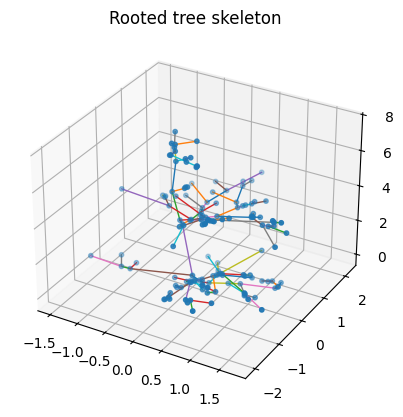

In [24]:
# Basic 3D plot of the skeleton
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# nodes
xyz = np.stack([G.nodes[n]['pos'] for n in G.nodes], axis=0)
ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], s=10)

# edges
for u, v in G.edges:
    pu = G.nodes[u]['pos']
    pv = G.nodes[v]['pos']
    ax.plot([pu[0], pv[0]], [pu[1], pv[1]], [pu[2], pv[2]], linewidth=1)

ax.set_title('Rooted tree skeleton')
plt.show()


## 3) Compute a legacy 0D persistence diagram for one filtration

"
"We'll use `path` by default (path length from root), normalized to [0,1].


In [ ]:
# Choose filtration: path / height / rho
f = filtration_height_z(G)
f = normalize_filtration_values(f, mode='minmax')

diag = compute_0d_persistence_diagram(G, f, include_infinite_bar=False)
print('diagram size:', diag.births.size)


TypeError: filtration_height_z() got an unexpected keyword argument 'weight_edges_by_euclidean'

## 4) Plot barcode and persistence diagram


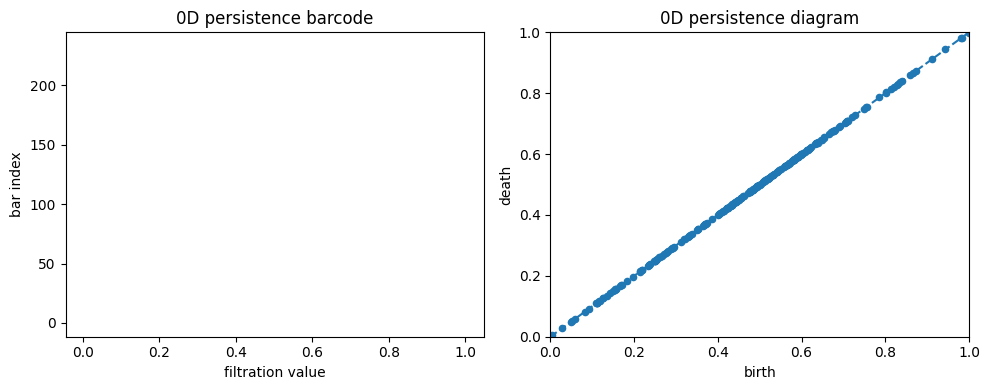

In [49]:
def plot_barcode_from_diagram(diag, ax=None):
    if ax is None:
        ax = plt.gca()
    pairs = diag.as_pairs()
    if pairs.size == 0:
        ax.set_title('Barcode (empty)')
        return ax
    lo = np.minimum(pairs[:,0], pairs[:,1])
    hi = np.maximum(pairs[:,0], pairs[:,1])
    order = np.argsort(lo)
    for i, idx in enumerate(order):
        ax.plot([lo[idx], hi[idx]], [i, i], linewidth=2)
    ax.set_xlabel('filtration value')
    ax.set_ylabel('bar index')
    ax.set_title('0D persistence barcode')
    return ax


def plot_diagram(diag, ax=None):
    if ax is None:
        ax = plt.gca()
    b = diag.births
    d = diag.deaths
    ax.scatter(b, d, s=20)
    ax.plot([0,1],[0,1], linestyle='--')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('birth'); ax.set_ylabel('death')
    ax.set_title('0D persistence diagram')
    return ax

fig, axs = plt.subplots(1,2, figsize=(10,4))
plot_barcode_from_diagram(diag, ax=axs[0])
plot_diagram(diag, ax=axs[1])
plt.tight_layout()
plt.show()


## 5) Persistence image (legacy)


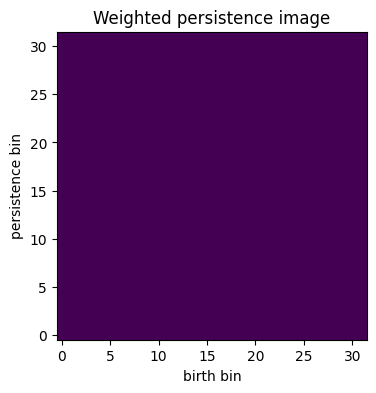

In [44]:
# Persistence image embedding (vector)
pi = persistence_image(diag, n_bins=32, sigma=0.05, weighting='persistence')

plt.figure(figsize=(4,4))
plt.imshow(pi.reshape(32,32), origin='lower', aspect='auto')
plt.title('Weighted persistence image')
plt.xlabel('birth bin'); plt.ylabel('persistence bin')
plt.show()


## 6) Full global embedding (multiple filtrations)

"
"This uses `compute_tmd_global_embedding` from the legacy utilities.


In [38]:
vec = compute_tmd_global_embedding(
    G,
    filtrations=('path','height','rho'),
    n_bins=32,
    sigma=0.05,
    normalize_mode='minmax',
    weighting='persistence',
)
print('global vec shape:', vec.shape)
print(vec.max())


global vec shape: (3072,)
0.31594342
